In [1]:
import chromedriver_autoinstaller
from bs4 import BeautifulSoup
from selenium import webdriver
import pandas as pd

In [2]:
chromedriver_autoinstaller.install()

'C:\\Users\\user\\anaconda3\\Lib\\site-packages\\chromedriver_autoinstaller\\145\\chromedriver.exe'

In [3]:
browser = webdriver.Chrome()

In [4]:
url = 'https://youtube-rank.com/board/bbs/board.php?bo_table=youtube'
browser.get(url)

In [5]:
html = browser.page_source
soup = BeautifulSoup(html, 'html.parser')

In [6]:
lst = soup.select('tr.aos-init')
len(lst)

100

In [7]:
# 100개의 정보뭉치 중 첫번째 원소를 선택하기
element = lst[0]
element

<tr class="aos-init aos-animate" data-aos="fade-up" data-aos-duration="800">
<td class="rank">
                        1                    </td>
<td class="td_img">
<div class="info_img"><a href="https://youtube-rank.com/board/bbs/board.php?bo_table=youtube&amp;wr_id=9663"><img class="lazyload" data-src="https://yt3.ggpht.com/61lpQx0TizD-UeJSv10975lLAt09xRHu0T8cz_6LnLGFwA_5L-Vz-Qa_GOXsthdkh8G7jXv1oQ=s88-c-k-c0x00ffffff-no-rj" height="88" src="https://yt3.ggpht.com/61lpQx0TizD-UeJSv10975lLAt09xRHu0T8cz_6LnLGFwA_5L-Vz-Qa_GOXsthdkh8G7jXv1oQ=s88-c-k-c0x00ffffff-no-rj" width="88"/></a></div>
<p class="info_rank">1</p>
</td>
<td class="subject">
<h1>
<p <a="" class="category" href="https://youtube-rank.com/board/bbs/board.php?bo_table=youtube&amp;sca=BJ%2F%EC%9D%B8%EB%AC%BC%2F%EC%97%B0%EC%98%88%EC%9D%B8">[BJ/인물/연예인]
                                
                                </p>
<a href="https://youtube-rank.com/board/bbs/board.php?bo_table=youtube&amp;wr_id=9663">
								
								김프

In [8]:
# element에서 랭킹, 유튜브카테고리, 유튜브명, 구독자수, view수, video수 수집하기

In [9]:
# 랭킹 수집하기
ranking = element.select('td.rank')
ranking

[<td class="rank">
                         1                    </td>]

In [10]:
# 랭킹 수집하기
ranking = element.select('td.rank')[0]
ranking

<td class="rank">
                        1                    </td>

In [11]:
# 랭킹 수집하기
ranking = element.select('td.rank')[0].text
ranking

'\n                        1                    '

In [12]:
# 랭킹 수집하기
ranking = element.select('td.rank')[0].text.strip()
ranking

'1'

In [13]:
'       \n  \t    dl    '.strip()

'dl'

In [14]:
# 유튜브 카테고리 수집하기
category = element.select('p.category')[0]
category

<p <a="" class="category" href="https://youtube-rank.com/board/bbs/board.php?bo_table=youtube&amp;sca=BJ%2F%EC%9D%B8%EB%AC%BC%2F%EC%97%B0%EC%98%88%EC%9D%B8">[BJ/인물/연예인]
                                
                                </p>

In [15]:
# 유튜브 카테고리 수집하기
category = element.select('p.category')[0].text
category

'[BJ/인물/연예인]\n                                \n                                '

In [16]:
# 유튜브 카테고리 수집하기
category = element.select('p.category')[0].text.strip()
category

'[BJ/인물/연예인]'

In [17]:
ranking = element.select('td.rank')[0].text.strip()
category = element.select('p.category')[0].text.strip()

In [18]:
# 유튜브명 수집하기
yutube_name = element.select('h1 > a')
yutube_name

[<a href="https://youtube-rank.com/board/bbs/board.php?bo_table=youtube&amp;wr_id=9663">
 								
 								김프로KIMPRO							</a>]

In [19]:
# 유튜브명 수집하기
yutube_name = element.select('h1 > a')[0]
yutube_name

<a href="https://youtube-rank.com/board/bbs/board.php?bo_table=youtube&amp;wr_id=9663">
								
								김프로KIMPRO							</a>

In [20]:
# 유튜브명 수집하기
yutube_name = element.select('h1 > a')[0].text.strip()
yutube_name

'김프로KIMPRO'

In [21]:
# 구독자 수 수집하기
subscriber_count = element.select('td.subscriber_cnt')[0].text
subscriber_count

'1억3000만'

In [22]:
# 조회수 수집하기
view_count = element.select('td.view_cnt')[0].text
view_count

'1327억5207만'

In [23]:
# video 수 수집하기
video_count = element.select('td.video_cnt')[0].text
video_count

'3,833개'

In [24]:
ranking = element.select('td.rank')[0].text.strip()
category = element.select('p.category')[0].text.strip()
yutube_name = element.select('h1 > a')[0].text.strip()
subscriber_count = element.select('td.subscriber_cnt')[0].text
view_count = element.select('td.view_cnt')[0].text
video_count = element.select('td.video_cnt')[0].text

element_lst = [ranking, category, yutube_name, subscriber_count, view_count, video_count]
element_lst

['1', '[BJ/인물/연예인]', '김프로KIMPRO', '1억3000만', '1327억5207만', '3,833개']

In [25]:
# 1개의 정보뭉치에서 정보 수집한 것을 반복해서 100개의 정보뭉치에서 정보 가져오기
result = []
for element in lst:
    ranking = element.select('td.rank')[0].text.strip()
    category = element.select('p.category')[0].text.strip()
    yutube_name = element.select('h1 > a')[0].text.strip()
    subscriber_count = element.select('td.subscriber_cnt')[0].text
    view_count = element.select('td.view_cnt')[0].text
    video_count = element.select('td.video_cnt')[0].text

    element_lst = [ranking, category, yutube_name, subscriber_count, view_count, video_count]

    result.append(element_lst)

In [26]:
result_df = pd.DataFrame(result, columns=['랭킹', '카테고리', '유튜브명', '구독자수', '조회수', '비디오수'])
result_df.head()

,랭킹,카테고리,유튜브명,구독자수,조회수,비디오수
0,1,[BJ/인물/연예인],김프로KIMPRO,1억3000만,1327억5207만,"3,833개"
1,2,[음악/댄스/가수],BLACKPINK,9980만,411억9500만,646개
2,3,[음악/댄스/가수],BANGTANTV,8220만,265억7827만,"2,963개"
3,4,[음악/댄스/가수],HYBE LABELS,7960만,436억3717만,"3,007개"
4,8,[음악/댄스/가수],SMTOWN,3350만,330억0440만,"4,665개"


1. '개', ',' 제거하기
2. '억', '만', 변환해서 숫자값으로 바꾸기

함수에 대한 정의

1. '개', ',' 제거하기 (replace)
2. '억', '만' 숫자를 실제 숫자로 변환
   1) '억' 글자의 위치를 찾고, 왼쪽에 있는 숫자 * 100000000

In [27]:
val = '360억2196만'

def convert_number(val): 
    
    #1. '개', ',' 제거하기 
    val = val.replace('개', '')
    val = val.replace(',', '')
    
    #2. '억' 위치를 찾고, 숫자 일부 변환하기 
    billion_index = val.find('억')
    # find : 주어진 문자열에서 찾고자 하는 문자열이 처음으로 나타나는 위치(인덱스)를 알려주는 함수 
    #        만약 주어진 문자열에 우리가 찾고자 하는 문자열이 없는 경우, -1 값을 반환합니다. 
    if billion_index != -1: 
        billion_part = float(val[:billion_index]) * 100000000 
        val = val[billion_index + 1:]
    else: 
        billion_part = 0 
        
    #3. '만' 위치를 찾고, 숫자 일부 변환하기 
    # val : '개', ',' 제거하고, '억'을 기준으로 우측에 있는 문자열 
    million_index = val.find('만')
    
    if million_index != -1: 
        million_part = float(val[:million_index]) * 10000 
        val = val[million_index + 1:]
    else: 
        million_part = 0 
        
    #4. '만' 글자 기준으로 오른쪽에 있는 숫자 * 1 
    # val : '개', ',' 제거하고, '억'을 기준으로 우측에 있는 문자열에서 '만'을 기준으로 우측에 있는 문자열 
    if val: 
        remaining = float(val) 
    else: 
        remaining = 0 
        
    # 5. 총합계산 
    total = billion_part + million_part + remaining
    
    return total 
    

In [28]:
val = '360억2196만'
convert_number(val) # 예상값: 36021960000 

36021960000.0

In [29]:
val = '9390만'
convert_number(val) #예상값: 93900000

93900000.0

In [30]:
convert_number(val)

93900000.0

In [35]:
# 컬럼에 우리가 만든 convert_number 함수를 일괄적용 
#범위.apply(함수) : 범위에 있는 값들을 함수에 하나씩 적용해서 반환하는 함수 

result_df['구독자수_숫자'] = result_df['구독자수'].apply(convert_number)
result_df['조회수_숫자'] = result_df['조회수'].apply(convert_number)
result_df['비디오수_숫자'] = result_df['비디오수'].apply(convert_number)

In [ ]:
pd.options.display.float_format = '{:,.0f}'.format

In [ ]:
result_df.info()

In [ ]:
result_df.head()

In [38]:
df = result_df[['랭킹', '카테고리', '유튜브명', '구독자수_숫자', '조회수_숫자', '비디오수_숫자']]
df.columns = ['랭킹', '카테고리', '유튜브명', '구독자수', '조회수', '비디오수']
df.head()

,랭킹,카테고리,유튜브명,구독자수,조회수,비디오수
0,1,[BJ/인물/연예인],김프로KIMPRO,130000000.0,1.327521e+11,3833.0
1,2,[음악/댄스/가수],BLACKPINK,99800000.0,4.119500e+10,646.0
2,3,[음악/댄스/가수],BANGTANTV,82200000.0,2.657827e+10,2963.0
3,4,[음악/댄스/가수],HYBE LABELS,79600000.0,4.363717e+10,3007.0
4,8,[음악/댄스/가수],SMTOWN,33500000.0,3.300440e+10,4665.0


In [39]:
# 업로드한 비디오 수가 가장 많은 유튜버 top10
df.sort_values(by='비디오수', ascending=False).head(10)

,랭킹,카테고리,유튜브명,구독자수,조회수,비디오수
94,117,[뉴스/정치/사회],MBCNEWS,6100000.0,2.687846e+10,364077.0
81,101,[TV/방송],SBS 스브스 Drama,7020000.0,8.574960e+09,352533.0
72,91,[TV/방송],SBS Entertainment,7490000.0,1.079746e+10,241175.0
57,72,[뉴스/정치/사회],MBCentertainment,9230000.0,1.878360e+10,112520.0
67,82,[뉴스/정치/사회],JTBC Entertainment,8210000.0,1.407217e+10,93423.0
15,20,[TV/방송],KBS WORLD TV,20400000.0,1.796789e+10,84427.0
74,93,[TV/방송],tvN DRAMA,7450000.0,1.049722e+10,76136.0
48,60,[TV/방송],KBS Kpop,10100000.0,1.184273e+10,61943.0
35,44,[TV/방송],MBCkpop,11400000.0,1.110621e+10,56197.0
13,18,[음악/댄스/가수],Mnet K-POP,22300000.0,1.882390e+10,44498.0


In [42]:
# 구독자수 대비 조회수가 많은 유튜브 top 10
df['구독자수 대비 조회수'] = df['조회수'] / df['구독자수']

df.sort_values(by='구독자수 대비 조회수', ascending=False).head(10)

C:\Users\user\AppData\Local\Temp\ipykernel_63376\3391895278.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['구독자수 대비 조회수'] = df['조회수'] / df['구독자수']


,랭킹,카테고리,유튜브명,구독자수,조회수,비디오수,구독자수 대비 조회수
94,117,[뉴스/정치/사회],MBCNEWS,6100000.0,2.687846e+10,364077.0,4406.304918
57,72,[뉴스/정치/사회],MBCentertainment,9230000.0,1.878360e+10,112520.0,2035.059588
67,82,[뉴스/정치/사회],JTBC Entertainment,8210000.0,1.407217e+10,93423.0,1714.028015
72,91,[TV/방송],SBS Entertainment,7490000.0,1.079746e+10,241175.0,1441.583445
78,98,[키즈/어린이],뽀로로(Pororo),7070000.0,1.016677e+10,5476.0,1438.015559
54,68,[음악/댄스/가수],Mnet TV,9470000.0,1.343502e+10,27936.0,1418.692714
74,93,[TV/방송],tvN DRAMA,7450000.0,1.049722e+10,76136.0,1409.022819
51,65,[스포츠/운동],팀일루션 노성율,9690000.0,1.291459e+10,1592.0,1332.775026
81,101,[TV/방송],SBS 스브스 Drama,7020000.0,8.574960e+09,352533.0,1221.504274
48,60,[TV/방송],KBS Kpop,10100000.0,1.184273e+10,61943.0,1172.547525


In [43]:
# 동영상 당 조회수가 많은 유튜브 top 10
df['동영상 당 조회수'] = df['조회수'] / df['비디오수']

df.sort_values(by='동영상 당 조회수', ascending=False).head(10)

C:\Users\user\AppData\Local\Temp\ipykernel_63376\2325632500.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['동영상 당 조회수'] = df['조회수'] / df['비디오수']


,랭킹,카테고리,유튜브명,구독자수,조회수,비디오수,구독자수 대비 조회수,동영상 당 조회수
40,49,[키즈/어린이],토이몽 TV - ToyMong Tv,10900000.0,9.359100e+08,12.0,85.863303,7.799250e+07
16,21,[음악/댄스/가수],officialpsy,20300000.0,1.272741e+10,183.0,626.966010,6.954869e+07
1,2,[음악/댄스/가수],BLACKPINK,99800000.0,4.119500e+10,646.0,412.775551,6.376935e+07
17,22,[음악/댄스/가수],ROSÉ,19600000.0,5.065090e+09,90.0,258.422959,5.627878e+07
7,12,[BJ/인물/연예인],승비니 Seungbini,30400000.0,2.687484e+10,722.0,884.040789,3.722277e+07
0,1,[BJ/인물/연예인],김프로KIMPRO,130000000.0,1.327521e+11,3833.0,1021.169769,3.463399e+07
5,9,[해외],Alan Becker,32500000.0,9.114310e+09,264.0,280.440308,3.452390e+07
65,80,[음악/댄스/가수],LLOUD Official,8350000.0,2.226710e+09,79.0,266.671856,2.818620e+07
9,14,[영화/만화/애니],GH'S,26800000.0,2.543323e+10,1099.0,949.001119,2.314216e+07
56,70,[회사/오피셜],The Beatles,9370000.0,8.824390e+09,453.0,941.770544,1.947989e+07


In [52]:
# 총 카테고리 개수
df['카테고리'].nunique()

11

In [53]:
df['카테고리'].unique()

array(['[BJ/인물/연예인]', '[음악/댄스/가수]', '[해외]', '[영화/만화/애니]', '[키즈/어린이]',
       '[TV/방송]', '[음식/요리/레시피]', '[게임]', '[스포츠/운동]', '[회사/오피셜]',
       '[뉴스/정치/사회]'], dtype=object)

In [54]:
df['카테고리'].value_counts()

카테고리
[음악/댄스/가수]     41
[키즈/어린이]       19
[음식/요리/레시피]    10
[TV/방송]         9
[BJ/인물/연예인]     7
[해외]            5
[뉴스/정치/사회]      3
[회사/오피셜]        3
[영화/만화/애니]      1
[스포츠/운동]        1
[게임]            1
Name: count, dtype: int64

In [55]:
df_category = pd.DataFrame(df['카테고리'].value_counts())
df_category

,count
카테고리,
[음악/댄스/가수],41
[키즈/어린이],19
[음식/요리/레시피],10
[TV/방송],9
[BJ/인물/연예인],7
[해외],5
[뉴스/정치/사회],3
[회사/오피셜],3
[영화/만화/애니],1


In [67]:
# 파이그래프 그리기
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

rc('font', family='Malgun Gothic')

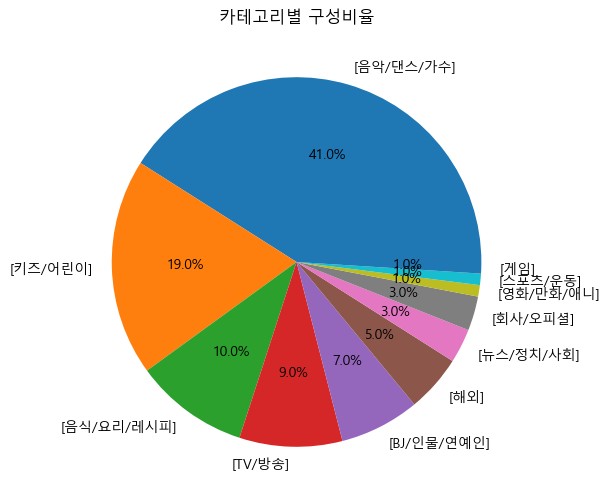

In [68]:
# 그래프의 크기 설정
plt.figure(figsize=(10,6))

# 파이차트 설정
plt.pie(df_category['count'], labels=df_category.index, autopct='%1.1f%%')

# 그래프 제목 달기]
plt.title('카테고리별 구성비율')

# 그래프 출력하기
plt.show()

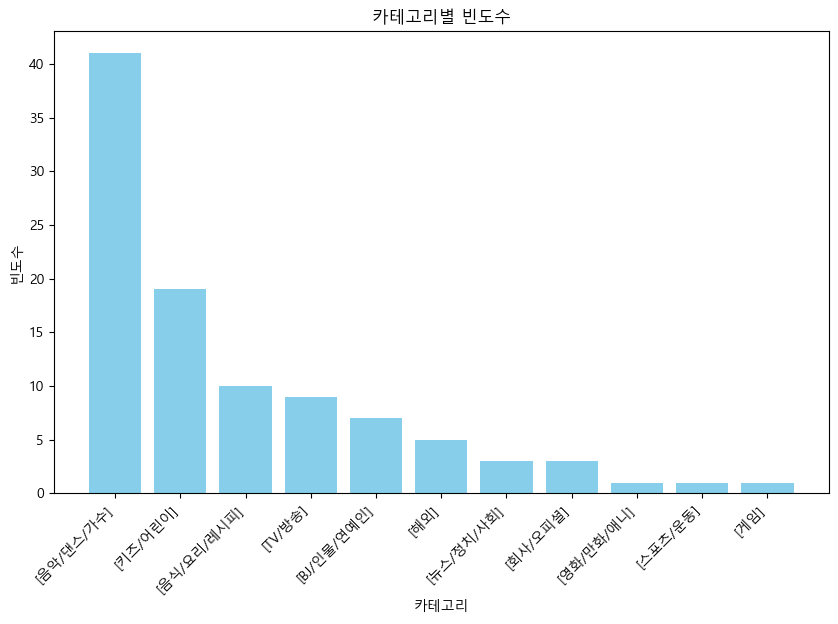

In [73]:
# 막대그래프 그리기

plt.figure(figsize=(10,6))

plt.bar(df_category.index, df_category['count'], color='skyblue')

plt.title('카테고리별 빈도수')
plt.xlabel('카테고리')
plt.ylabel('빈도수')

# x축 라벨 각도 비틀기
plt.xticks(rotation=45, ha='right') # ha: left/right/center

plt.show()

In [78]:
# 어떤 카테고리의 평균 구독자수가 많은가? - 카테고리 별 평균 구독자 수

df_pivot = df.pivot_table(index='카테고리', values='구독자수', aggfunc='mean')

# aggfunc
# mean: 평균, sum: 합계, count: 개수, min: 최소값, max: 최대값, median: 중위수, std: 표준편차, var: 분산, nunique: 고유한 값의 개수, 사용자가 정의한 함수

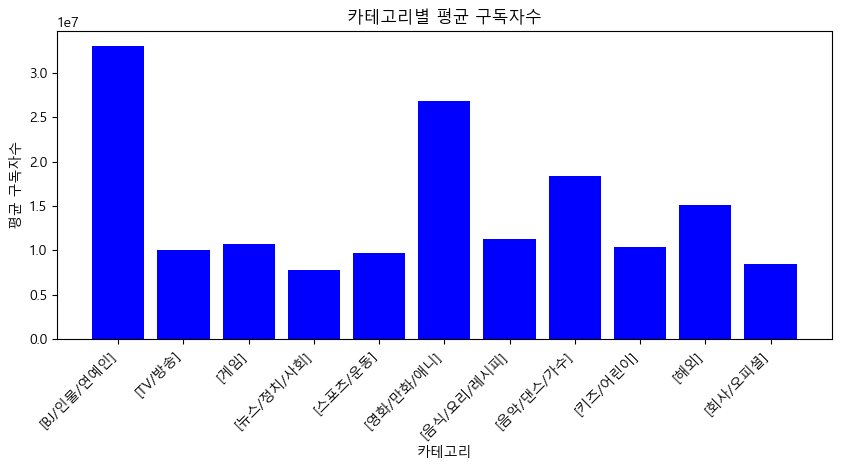

In [79]:
# 막대그래프 그리기

plt.figure(figsize=(10,4))

# 그래프 그리기
plt.bar(df_pivot.index, df_pivot['구독자수'], color='blue')

plt.title('카테고리별 평균 구독자수')

plt.xlabel('카테고리')
plt.ylabel('평균 구독자수')

plt.xticks(rotation=45, ha='right')

plt.show()

In [80]:
# 어떤 카테고리에 평균 동영상 수가 많은가? - 카테고리 별 평균 동영상 개수
df_pivot_video = df.pivot_table(index='카테고리', values='비디오수', aggfunc='mean')
df_pivot_video

,비디오수
카테고리,
[BJ/인물/연예인],2492.571429
[TV/방송],104994.888889
[게임],519.000000
[뉴스/정치/사회],190006.666667
[스포츠/운동],1592.000000
[영화/만화/애니],1099.000000
[음식/요리/레시피],1833.700000
[음악/댄스/가수],5176.463415
[키즈/어린이],1600.631579


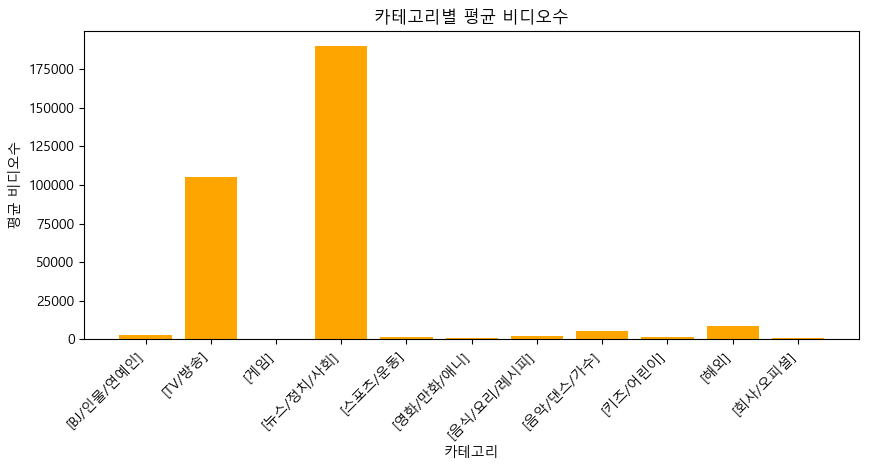

In [83]:
plt.figure(figsize=(10,4))

plt.bar(df_pivot_video.index, df_pivot_video['비디오수'], color='orange')

plt.title('카테고리별 평균 비디오수')

plt.xlabel('카테고리')
plt.ylabel('평균 비디오수')

plt.xticks(rotation=45, ha='right')

plt.show()

In [85]:
# 카테고리 별 최대/최소 동영상 업로드 수에 차이가 있는가? - 카테고리 별 최대 동영상 업로드 수, 최저 동영상 업로드 수
df_pivot_video_minmax = df.pivot_table(index='카테고리', values='비디오수', aggfunc=['min', 'max'])
df_pivot_video_minmax

,min,max
,비디오수,비디오수
카테고리,,
[BJ/인물/연예인],128.0,9273.0
[TV/방송],2142.0,352533.0
[게임],519.0,519.0
[뉴스/정치/사회],93423.0,364077.0
[스포츠/운동],1592.0,1592.0
[영화/만화/애니],1099.0,1099.0
[음식/요리/레시피],626.0,6458.0
[음악/댄스/가수],79.0,44498.0
